# Stochastic transmission through the sample — XRT (incident) vs SEER (transmitted)

Companion to `mfx101609126_droplet_spook_rixs.ipynb`. Here we exploit the fact
that the **SEER spectrometer sits downstream of the sample** while the **XRT
spectrometer measures the incident SASE spectrum upstream**. Both disperse the
*same* shot-to-shot-jittering incident spectrum in photon energy, so their
shot-to-shot covariance encodes how the sample modifies the beam as a function
of energy — i.e. the **stochastic (relative) transmission** `T(E)`.

```
   SASE beam --> [XRT spectrometer] --> [SAMPLE] --> [SEER spectrometer]
                     incident A            T(E)         transmitted B
```

**What we can and cannot recover.** XRT (`xrt_hproj`) is in raw feespec units
(~1e8/shot) and SEER (`epix_seer_ROI_1`) is photon-counted (~1e2/shot); they are
different detectors with different solid angles and gains. The *absolute*
transmission is therefore not directly accessible. What the stochastic
correlation recovers is the **energy-dependent SHAPE** of the transmission (up
to one overall scale factor). For the **Fe-foil runs 78-82** this shape should
carry the Fe K-edge (~7112 eV) if it lies within the spectral window.

**Two views (per the analysis plan):**
1. **Covariance map** — spook with `A = XRT`, `B = SEER` gives the full 2D
   incident-vs-transmitted energy-energy map. A clean sample would show a bright
   diagonal ridge (energy is conserved through transmission).
2. **Ridge transmission** — the per-XRT-bin regression slope `cov(XRT,SEER)/var(XRT)`
   along the matched-energy ridge gives the 1D relative-transmission curve.

No energy calibration is applied yet — everything is on the pixel axis. The
code is structured so a pixel->eV map can be dropped in later.

In [1]:
# 78-82 Fe foil
import os
os.chdir(os.path.dirname(os.path.abspath('__file__')) + '/..')

import h5py
import numpy as np
import matplotlib.pyplot as plt
from spook import SpookLinSolve

## 1. Load the droplet-reconstructed per-shot spectra (runs 78-82, aggregated)

Same inputs as the RIXS notebook: xray-on-filtered per-shot spectra written by
`regenerate_droplet_pershot.py`. We pool every run along the shot axis so the
shot-to-shot statistics span the full dataset.

In [2]:
RUNS   = [78, 79, 80, 81, 82]        # Fe foil
H5_DIR = 'examples/results/mfx101609126_droplet_pershot_xes'

xrt_list, seer_list, ipm_list, run_id_list = [], [], [], []
for r in RUNS:
    with h5py.File(f'{H5_DIR}/run{r:04d}.h5', 'r') as f:
        xr = f['xrt_hproj'][:].astype(float)   # (n_r, 2048) — XRT incident (upstream)
        se = f['epix_seer_ROI_1'][:].astype(float)  # (n_r, 768) — SEER transmitted (downstream)
        im = f['ipm'][:]
    n_r = xr.shape[0]
    xrt_list.append(xr); seer_list.append(se); ipm_list.append(im)
    run_id_list.append(np.full(n_r, r, dtype=int))
    print(f'  run {r:04d}: {n_r:5d} xray shots')

xrt_raw   = np.concatenate(xrt_list,  axis=0)   # (N, 2048)
epix_seer = np.concatenate(seer_list, axis=0)   # (N, 768)
ipm       = np.concatenate(ipm_list,  axis=0)   # (N,)
run_id    = np.concatenate(run_id_list, axis=0) # (N,)

print(f'\nAggregated shots: {xrt_raw.shape[0]}  (runs {RUNS})')
print(f'xrt_raw (incident):    {xrt_raw.shape}')
print(f'epix_seer (transmitted): {epix_seer.shape}')

  run 0078:  1192 xray shots
  run 0079:  2843 xray shots
  run 0080:  2850 xray shots
  run 0081:  2980 xray shots
  run 0082:   668 xray shots



Aggregated shots: 10533  (runs [78, 79, 80, 81, 82])
xrt_raw (incident):    (10533, 2048)
epix_seer (transmitted): (10533, 768)


## 2. Build incident `A` (XRT) and transmitted `B` (SEER) matrices

1. crop each spectrometer to its active energy window,
2. bin lightly to improve per-bin S/N and condition the solve,
3. mean-subtract to isolate the shot-to-shot fluctuations that carry the
   energy-correlation information.

Both `A` and `B` now disperse the *same* incident SASE spectrum in energy — `A`
before the sample, `B` after — so their covariance is shaped by `T(E)`.

In [3]:
# --- Incident A: XRT (crop + bin) ---
XRT_LO, XRT_HI, XRT_BIN = 301, 1833, 16     # active XRT window
xc = xrt_raw[:, XRT_LO:XRT_HI]
nx = xc.shape[1] // XRT_BIN
Xb = xc[:, :nx*XRT_BIN].reshape(xc.shape[0], nx, XRT_BIN).sum(2)
A = Xb - Xb.mean(0)

# --- Transmitted B: SEER (crop to active line + bin) ---
SEER_LO, SEER_HI, SEER_BIN = 160, 400, 4    # active SEER window (full-panel cols)
sc = epix_seer[:, SEER_LO:SEER_HI]
ns = sc.shape[1] // SEER_BIN
Sb = sc[:, :ns*SEER_BIN].reshape(sc.shape[0], ns, SEER_BIN).sum(2)
B = Sb - Sb.mean(0)
TrBtB = float(np.sum(B**2))

# Patched ASIC gap columns (full-panel) inside the SEER crop -> flag as artifacts.
# (Same collinearity artifact as in the RIXS notebook: the polynomial gap-patch
#  makes these SEER bins linear combos of neighbors, so they carry no independent
#  transmission info and show up as stripes.)
GAP_COLS_FULL = [191, 287, 383]
seer_gap_bins = [int((g - SEER_LO) // SEER_BIN) for g in GAP_COLS_FULL]

AtA = A.T @ A
AtB = A.T @ B
print(f'Incident   A (XRT):  {A.shape}   cond(AtA)={np.linalg.cond(AtA):.2e}')
print(f'Transmitted B (SEER): {B.shape}   Tr(BtB)={TrBtB:.3e}')
print(f'SEER gap-artifact bins: {seer_gap_bins}')

Incident   A (XRT):  (10533, 95)   cond(AtA)=4.14e+05
Transmitted B (SEER): (10533, 60)   Tr(BtB)=1.353e+07
SEER gap-artifact bins: [7, 31, 55]


## 3. View 1 — incident-vs-transmitted covariance map

spook L2 solve with `A = XRT` (incident) and `B = SEER` (transmitted). The
recovered map `X` is `(n_XRT x n_SEER)`: element `(i, j)` is how strongly a
fluctuation at XRT energy-bin `i` drives the transmitted intensity at SEER
energy-bin `j`. Because energy is conserved through simple transmission, the
map should be dominated by a **diagonal ridge** — its brightness along the
diagonal traces the transmission shape.

Covariance map: (95, 60)   max=2.194e-07  min=-5.515e-08


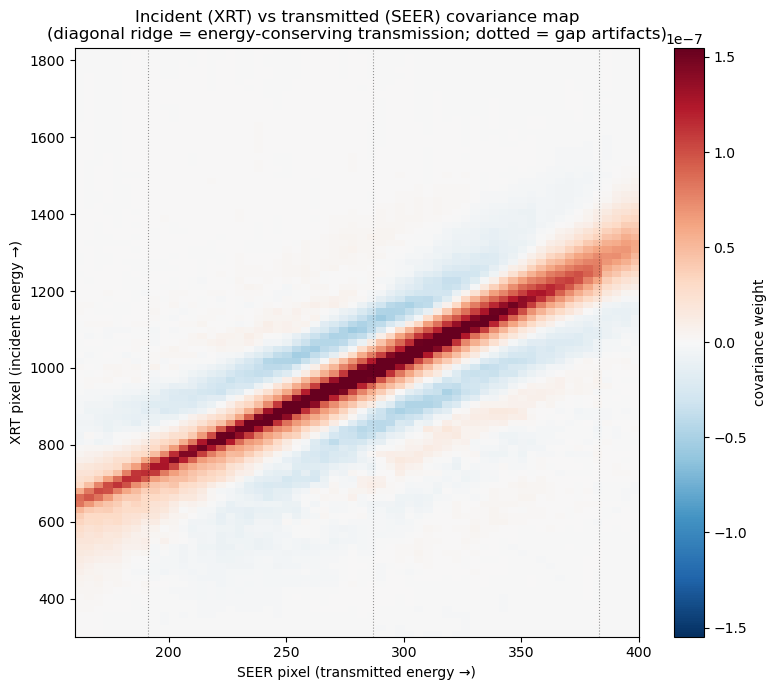

In [4]:
LSMOOTH = (1e-3, 1e-3)
spk = SpookLinSolve(AtB, AtA, mode='contracted', lsmooth=LSMOOTH)
spk.set_btb(TrBtB)
X_map = spk.getXopt()          # (n_XRT, n_SEER)
print(f'Covariance map: {X_map.shape}   max={X_map.max():.3e}  min={X_map.min():.3e}')

fig, ax = plt.subplots(figsize=(8, 7))
v = np.percentile(np.abs(X_map), 99)
im = ax.imshow(X_map, aspect='auto', origin='lower', cmap='RdBu_r', vmin=-v, vmax=v,
               extent=[SEER_LO, SEER_HI, XRT_LO, XRT_HI])
plt.colorbar(im, ax=ax, label='covariance weight')
for g in GAP_COLS_FULL:
    ax.axvline(g, color='k', ls=':', lw=0.8, alpha=0.4)
ax.set_xlabel('SEER pixel (transmitted energy \u2192)')
ax.set_ylabel('XRT pixel (incident energy \u2192)')
ax.set_title('Incident (XRT) vs transmitted (SEER) covariance map\n(diagonal ridge = energy-conserving transmission; dotted = gap artifacts)')
plt.tight_layout(); plt.show()

## 4. View 2 — ridge transmission `T(E)`

For every XRT (incident) energy bin `i` we find the SEER bin `j*` it most
strongly correlates with (the ridge), then take the shot-to-shot **regression
slope**

$$ T_i \;\propto\; \frac{\mathrm{cov}(\mathrm{XRT}_i,\ \mathrm{SEER}_{j^*})}{\mathrm{var}(\mathrm{XRT}_i)} $$

This slope is the transmitted-per-incident response at that energy — the
**relative transmission shape** (up to the constant XRT/SEER gain ratio). We
only trust bins where the ridge correlation clears a threshold (elsewhere one
spectrometer has no signal and the slope is meaningless).

**Absorption view (for easy visual recognition).** Absorbance follows
Beer\u2013Lambert: `A(E) = \u03bc(E)\u00b7t = -ln T(E)`. Since our `T` is only
relative (known up to a constant gain factor `g`), taking `-ln(g\u00b7T)` just
shifts the curve by the additive constant `-ln g`, which **cannot create,
remove, or distort an edge** \u2014 it only sets the vertical offset. So the
log-transform flips the transmission step-*down* into the familiar absorption
step-*up* at the Fe K-edge, purely for visualization. (We subtract the median
so the y-axis is a relative absorbance \u0394\u03bct.)

trusted XRT bins (corr>0.4, off-gap): 63/95


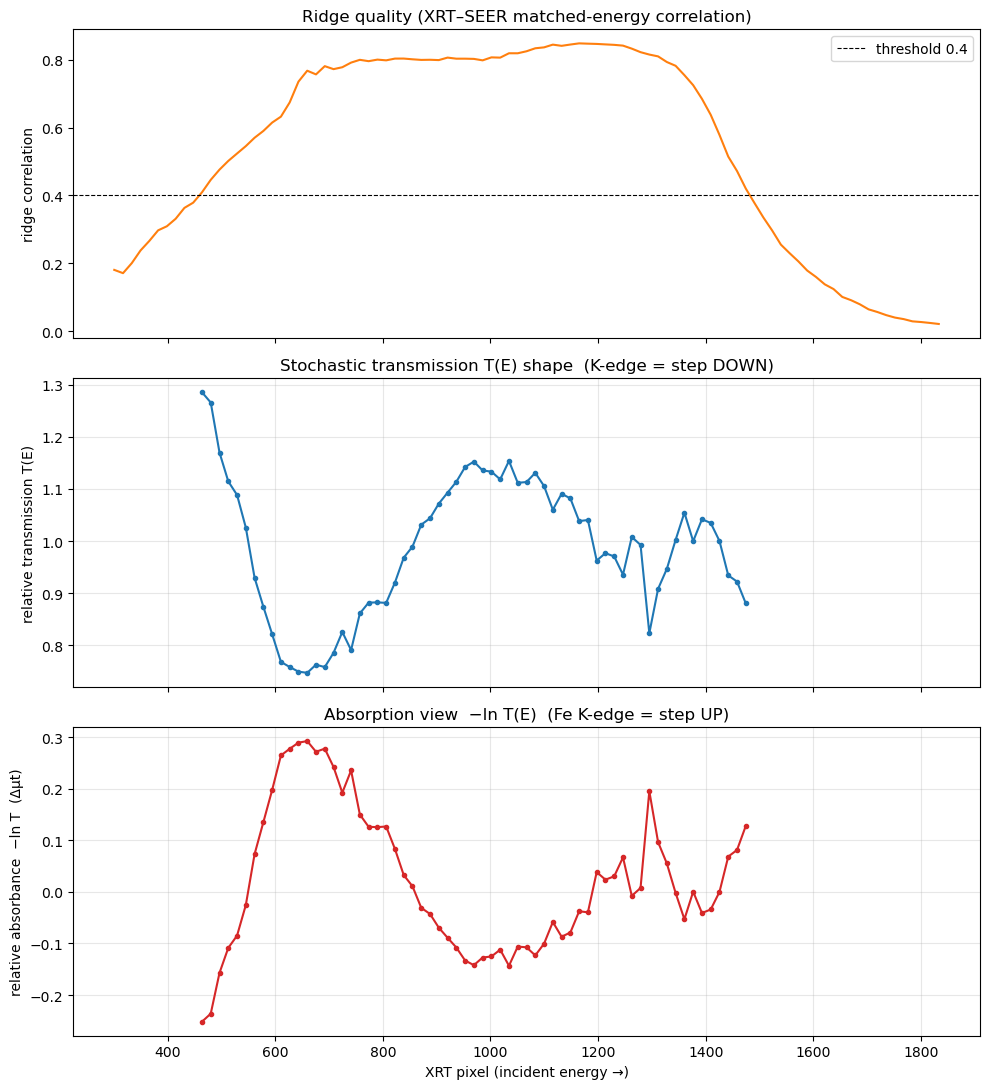

In [5]:
CORR_MIN = 0.4     # minimum ridge correlation to trust a bin

# normalized cross-correlation matrix (XRT bins x SEER bins)
An = A / (A.std(0) + 1e-9)
Bn = B / (B.std(0) + 1e-9)
C = (An.T @ Bn) / A.shape[0]

ridge = C.argmax(1)          # best-matching SEER bin per XRT bin
peak  = C.max(1)             # its correlation

# regression slope of the matched SEER bin on each XRT bin (shot-to-shot)
var_x  = A.var(0)
cov_xy = (A * B[:, ridge]).mean(0)
slope  = cov_xy / (var_x + 1e-9)      # relative transmission * gain

trusted = peak > CORR_MIN
# also drop XRT bins whose ridge lands on a SEER gap-artifact bin
trusted &= ~np.isin(ridge, seer_gap_bins)

xrt_px = np.linspace(XRT_LO, XRT_HI, nx)
T = np.where(trusted, slope, np.nan)
# normalize the shape to its trusted median for a readable y-axis
T_norm = T / np.nanmedian(T)

# Absorption view: A = -ln(T). T is relative (up to a gain constant), so we
# normalize by the median first; the additive -ln(median) offset cannot alter
# the edge shape. Only positive T bins are physical for the log.
T_pos = np.where(T_norm > 0, T_norm, np.nan)
absorb = -np.log(T_pos)
absorb = absorb - np.nanmedian(absorb)     # relative absorbance \u0394\u03bct

print(f'trusted XRT bins (corr>{CORR_MIN}, off-gap): {int(trusted.sum())}/{nx}')

fig, axes = plt.subplots(3, 1, figsize=(10, 11), sharex=True)
axes[0].plot(xrt_px, peak, color='C1')
axes[0].axhline(CORR_MIN, color='k', ls='--', lw=0.8, label=f'threshold {CORR_MIN}')
axes[0].set_ylabel('ridge correlation'); axes[0].legend()
axes[0].set_title('Ridge quality (XRT\u2013SEER matched-energy correlation)')

axes[1].plot(xrt_px, T_norm, 'o-', ms=3, color='C0')
axes[1].set_ylabel('relative transmission T(E)')
axes[1].set_title('Stochastic transmission T(E) shape  (K-edge = step DOWN)')
axes[1].grid(alpha=0.3)

axes[2].plot(xrt_px, absorb, 'o-', ms=3, color='C3')
axes[2].set_xlabel('XRT pixel (incident energy \u2192)')
axes[2].set_ylabel('relative absorbance  \u2212ln T  (\u0394\u03bct)')
axes[2].set_title('Absorption view  \u2212ln T(E)  (Fe K-edge = step UP)')
axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Cross-check — ridge overlaid on the covariance map

Sanity check that the extracted ridge follows the bright diagonal of the
covariance map. A straight, monotonic ridge confirms the two spectrometers are
dispersing the same energy axis and that the transmission slope is being read
along the correct (matched-energy) direction.

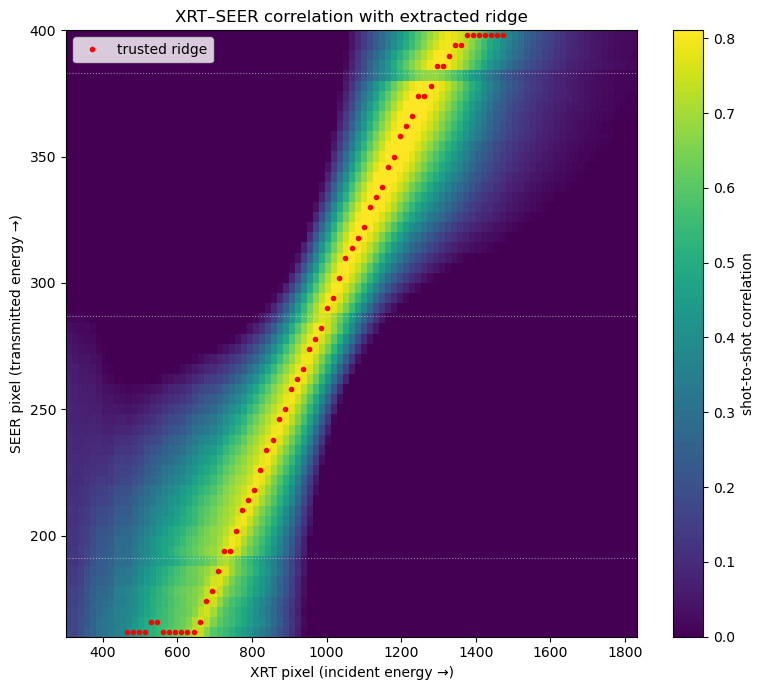

In [6]:
fig, ax = plt.subplots(figsize=(8, 7))
v = np.percentile(np.abs(C), 99)
im = ax.imshow(C.T, aspect='auto', origin='lower', cmap='viridis',
               extent=[XRT_LO, XRT_HI, SEER_LO, SEER_HI], vmin=0, vmax=v)
plt.colorbar(im, ax=ax, label='shot-to-shot correlation')
# ridge (only trusted bins) in SEER pixel units
ridge_px = SEER_LO + (ridge + 0.5) * SEER_BIN
ax.plot(xrt_px[trusted], ridge_px[trusted], 'r.', ms=6, label='trusted ridge')
for g in GAP_COLS_FULL:
    ax.axhline(g, color='w', ls=':', lw=0.8, alpha=0.5)
ax.set_xlabel('XRT pixel (incident energy \u2192)')
ax.set_ylabel('SEER pixel (transmitted energy \u2192)')
ax.set_title('XRT\u2013SEER correlation with extracted ridge')
ax.legend(loc='upper left')
plt.tight_layout(); plt.show()

## Notes

- **What the transmission shape means.** `T(E)` here is the *relative* energy
  dependence of the sample transmission, recovered purely from shot-to-shot SASE
  jitter shared between the upstream (XRT) and downstream (SEER) spectrometers.
  It is defined only up to the (unknown, constant) XRT/SEER gain ratio, so read
  the *shape* (edges, slopes), not the absolute value.
- **Fe K-edge.** Runs 78-82 are Fe foil. If the incident window spans ~7112 eV
  the transmission should show the characteristic absorption-edge step. Confirm
  by adding an energy calibration (pixel->eV) for both spectrometers.
- **Transmission vs absorption.** The K-edge is a step **DOWN** in transmission
  `T(E)` (more absorption above the edge = less transmitted beam) and therefore
  a step **UP** in absorbance `\u2212ln T`. The low-transmission / high-absorbance
  side is the high-energy side of the edge. The absorption panel is a
  visualization aid only: because `T` is relative, `\u2212ln T` is correct up to
  an additive constant, which shifts the curve vertically but preserves the edge.
  Without a pixel->eV calibration the horizontal orientation (which way is higher
  energy) depends on the spectrometer dispersion sign.
- **Gap artifacts.** SEER bins on the patched ASIC gaps (full-panel cols ~191,
  287, 383) are collinear with their neighbors and carry no independent info;
  they are excluded from the trusted ridge and flagged on the maps.
- **Absolute transmission.** To go beyond a shape you need matched detectors /
  a gain cross-calibration, or a reference (no-sample) run to divide out the
  spectrometer response.
- **Robustness.** Raise `CORR_MIN` to keep only the cleanest ridge; increase
  `XRT_BIN`/`SEER_BIN` for more S/N per bin at the cost of energy resolution.